# 7. Deutsch-Jozsa Algorithm

We're given a hidden function `f` that takes `n` bits and returns
either `0` or `1`. We're promised `f` is either:
- **constant**: same output for every input, or
- **balanced**: outputs `0` for exactly half the inputs and `1` for
  the other half

Classically, you might need to check more than half the inputs to
be sure. The Deutsch-Jozsa algorithm tells you which one it is with
a **single run** on a quantum computer.

We'll use `n = 3` input qubits, plus 1 helper ("ancilla") qubit.

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
n = 3  # number of input qubits

## Case 1: Constant oracle

A constant oracle either always outputs 0 (does nothing to the
ancilla) or always outputs 1 (always flips the ancilla). Here we
build the "always outputs 1" version.

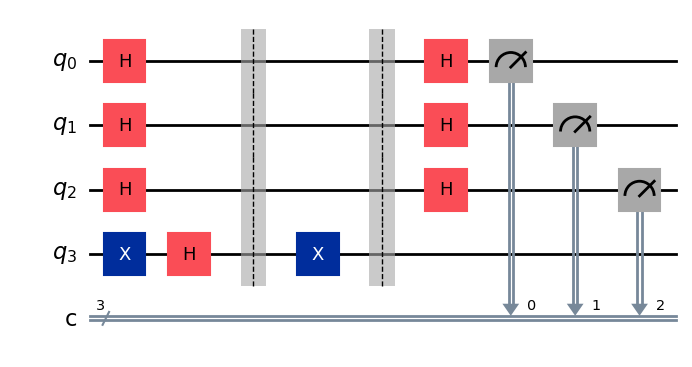

In [2]:
qc_constant = QuantumCircuit(n + 1, n)

# Ancilla qubit (last qubit) starts at |1>, then Hadamard -> |->
qc_constant.x(n)
qc_constant.h(n)

# Input qubits in superposition
for i in range(n):
    qc_constant.h(i)

qc_constant.barrier()

# --- Constant oracle: always flip the ancilla, no matter the input ---
qc_constant.x(n)

qc_constant.barrier()

# Interference: Hadamard on the input qubits again
for i in range(n):
    qc_constant.h(i)

qc_constant.measure(range(n), range(n))
qc_constant.draw("mpl")

Measurement counts: {'000': 1024}


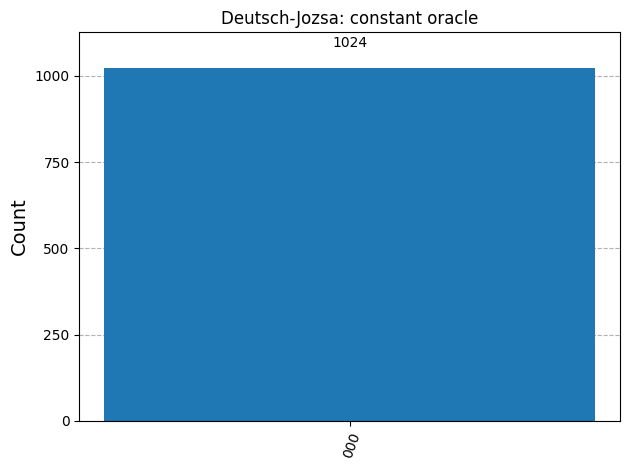

In [3]:
counts_constant = simulator.run(transpile(qc_constant, simulator), shots=1024).result().get_counts()
print("Measurement counts:", counts_constant)
plot_histogram(counts_constant, title="Deutsch-Jozsa: constant oracle")

In [4]:
measured_constant = max(counts_constant, key=counts_constant.get)
verdict_constant = "CONSTANT" if measured_constant == "0" * n else "BALANCED"
print("Most frequent result:", measured_constant)
print("Verdict:", verdict_constant, "-- correct answer was CONSTANT")

Most frequent result: 000
Verdict: CONSTANT -- correct answer was CONSTANT


## Case 2: Balanced oracle

A balanced oracle uses CNOT gates from each input qubit to the
ancilla — this makes the ancilla flip for exactly half of all
possible inputs.

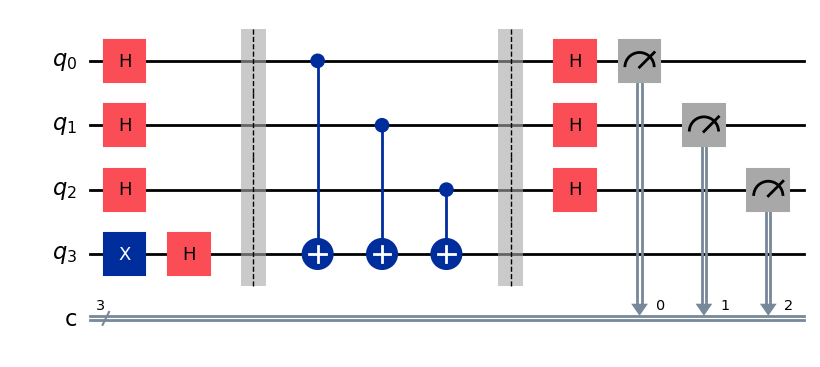

In [5]:
qc_balanced = QuantumCircuit(n + 1, n)

qc_balanced.x(n)
qc_balanced.h(n)

for i in range(n):
    qc_balanced.h(i)

qc_balanced.barrier()

# --- Balanced oracle: CNOT from every input qubit to the ancilla ---
for i in range(n):
    qc_balanced.cx(i, n)

qc_balanced.barrier()

for i in range(n):
    qc_balanced.h(i)

qc_balanced.measure(range(n), range(n))
qc_balanced.draw("mpl")

Measurement counts: {'111': 1024}


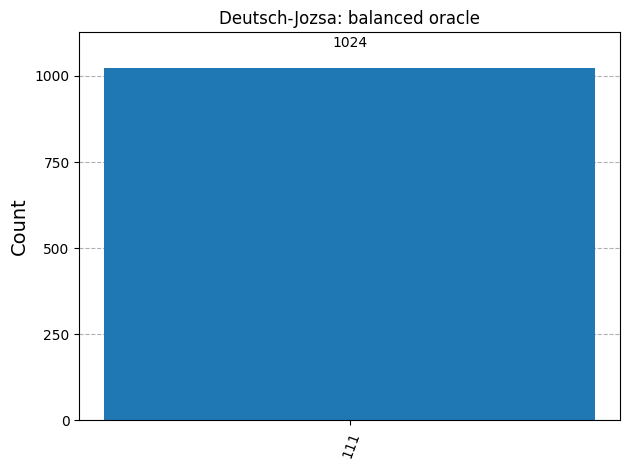

In [6]:
counts_balanced = simulator.run(transpile(qc_balanced, simulator), shots=1024).result().get_counts()
print("Measurement counts:", counts_balanced)
plot_histogram(counts_balanced, title="Deutsch-Jozsa: balanced oracle")

In [7]:
measured_balanced = max(counts_balanced, key=counts_balanced.get)
verdict_balanced = "CONSTANT" if measured_balanced == "0" * n else "BALANCED"
print("Most frequent result:", measured_balanced)
print("Verdict:", verdict_balanced, "-- correct answer was BALANCED")

Most frequent result: 111
Verdict: BALANCED -- correct answer was BALANCED


## Summary

- All-zero measurement (`'000'`) -> the function is **constant**
- Any other measurement -> the function is **balanced**

Both cases above were correctly identified using only one run of
each circuit.